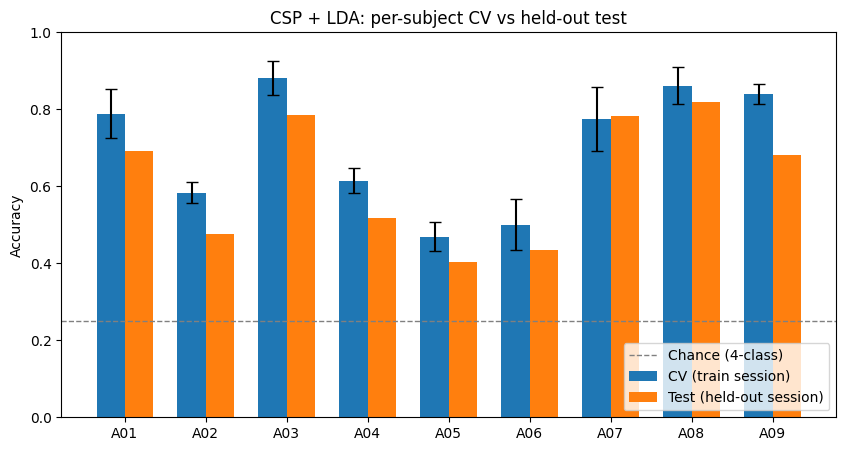

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

results_path = Path("../results/best_hyperparameters.json")
with open(results_path) as f:
    results = sorted(json.load(f), key=lambda r: r["subject_id"])

subjects  = [f"A0{r['subject_id']}" for r in results]
cv_accs   = [r["cv_acc"]  for r in results]
cv_stds   = [r["cv_std"]  for r in results]
test_accs = [r["test_acc"] for r in results]

x = np.arange(len(subjects)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, cv_accs,   width, yerr=cv_stds, capsize=4, label="CV (train session)")
ax.bar(x + width/2, test_accs, width, label="Test (held-out session)")
ax.axhline(0.25, color="grey", linestyle="--", linewidth=1, label="Chance (4-class)")
ax.set_xticks(x); ax.set_xticklabels(subjects)
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1)
ax.set_title("CSP + LDA: per-subject CV vs held-out test")
ax.legend(loc="lower right")
fig.savefig("per_subject_bars.png", dpi=150, bbox_inches="tight")
plt.show()

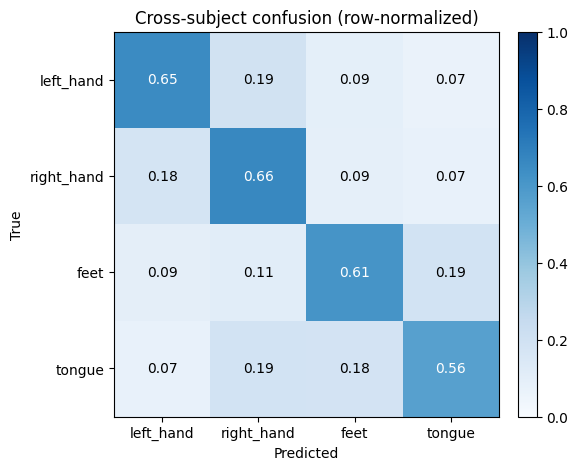

In [3]:
CLASS_NAMES = ["left_hand", "right_hand", "feet", "tongue"]  # verify ordering matches your CLASS_LABELS dict

confusion_sum = np.sum([np.array(r["confusion_mat"]) for r in results], axis=0)
cm_norm = confusion_sum / confusion_sum.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks(range(4)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Cross-subject confusion (row-normalized)")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                color="white" if cm_norm[i,j] > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()